In [1]:
import numpy as np
import matplotlib.pyplot as plt
import croak

def center(t, intensity):
    i = int(np.argmax(intensity))
    return t - t[i], intensity / intensity.max()

def temporal_intensity(grid, ew):
    return np.abs(grid.ifft(ew)) ** 2

g = croak.Grid(128, dt=0.4e-15)
omega0 = croak.maths.wlfreq(800e-9)

In [2]:
ew_true = croak.gaussian_pulse(g, 5e-15, phases=[40e-30, 300e-45])
delays = np.linspace(-60e-15, 60e-15, 90)
trace = croak.maketrace(g.omega, delays, ew_true, "pg")

res = croak.retrieve(trace, g.omega, delays, "pg", algorithm="copra",
                    maxiters=250, rng=np.random.default_rng(0))
I_retr = temporal_intensity(g, res.spectrum)
print(f"trace error R  = {res.error:.2e}")
print(f"retrieved FWHM = {croak.maths.fwhm(*center(g.t, I_retr)) * 1e15:.2f} fs")

retrieving:   0%|          | 0/250 [00:00<?, ?it/s]

retrieval complete — copra / pg
  final error R    : 0.0000%
  retrieved FWHM   : 11.25 fs
  transform limit  : 5.00 fs
  iterations       : 250
  time taken       : 2.01 s
trace error R  = 2.30e-15
retrieved FWHM = 11.25 fs


In [3]:
gdd, tod, fod = croak.dispersion.auto_taylor(g, res.spectrum, res.omega0)
print(f"compensating dispersion: GDD = {gdd/1e-30:.0f} fs²,  "
      f"TOD = {tod/1e-45:.0f} fs³")

compressed = croak.apply_dispersion(g.omega, res.omega0, res.spectrum,
                                   gdd=gdd, tod=tod, fod=fod)
I_comp = temporal_intensity(g, compressed)

print(f"peak-power gain  = {I_comp.max() / I_retr.max():.2f}×")
print(f"compressed FWHM  = {croak.maths.fwhm(*center(g.t, I_comp)) * 1e15:.2f} fs")

compensating dispersion: GDD = 3089 fs²,  TOD = -7098 fs³
peak-power gain  = 2.52×
compressed FWHM  = 5.01 fs


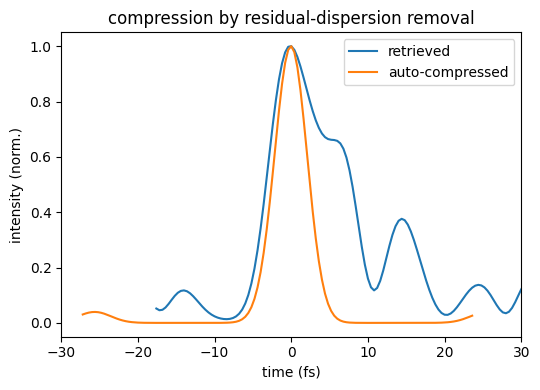

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for label, I in [("retrieved", I_retr), ("auto-compressed", I_comp)]:
    tc, ic = center(g.t, I)
    ax.plot(tc * 1e15, ic, label=label)
ax.set_xlim(-30, 30)
ax.set_xlabel("time (fs)")
ax.set_ylabel("intensity (norm.)")
ax.set_title("compression by residual-dispersion removal")
ax.legend()
fig.tight_layout()